In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, recall_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('DB_LIMPIA.csv', sep=";")
df.head(5)

,Unnamed: 0,VIC_SEXO,VIC_EDAD,TOTAL_HIJOS,VIC_ESCOLARIDAD,VIC_EST_CIV,VIC_GRUPET,VIC_TRABAJA,VIC_DISC,VIC_REL_AGR,...,HEC_TIPAGRE,INST_DONDE_DENUNCIO,AGR_SEXO,AGR_EDAD,AGR_ESCOLARIDAD,AGR_EST_CIV,AGR_GRUPET,AGR_TRABAJA,INST_DENUN_HECHO,MEDIDAS_SEGURIDAD
0,0,Mujeres,11,-1,Primaria,Desconocido,Ladino,No,Desconocido,Hijos(as),...,Física-sexual,NaN,Hombres,58,Primaria,Soltero,Ladino,No,Ministerio Público,Desconocido
1,1,Hombres,4,-1,Desconocido,Desconocido,Ladino,Desconocido,No,Hijos(as),...,Física-psicológica,NaN,Mujeres,27,Primaria,Soltero,Ladino,Si,Procuraduría de los Derechos Humanos,Desconocido
2,2,Hombres,11,-1,Primaria,Desconocido,Ladino,No,No,Hijos(as),...,Física-psicológica,NaN,Hombres,35,Ninguna,Unido,Ladino,Si,Procuraduría de los Derechos Humanos,Desconocido
3,3,Mujeres,6,-1,Desconocido,Desconocido,Ladino,Desconocido,No,Hijos(as),...,Psicológica,NaN,Hombres,35,Primaria,Soltero,Ladino,Si,Organismo Judicial,Si
4,4,Hombres,11,-1,Primaria,Desconocido,Ladino,No,No,Hijos(as),...,Psicológica,NaN,Hombres,35,Primaria,Soltero,Ladino,Si,Organismo Judicial,Si


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 358998 entries, 0 to 358997
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           358998 non-null  int64
 1   VIC_SEXO             358998 non-null  str  
 2   VIC_EDAD             358998 non-null  int64
 3   TOTAL_HIJOS          358998 non-null  int64
 4   VIC_ESCOLARIDAD      358998 non-null  str  
 5   VIC_EST_CIV          358998 non-null  str  
 6   VIC_GRUPET           358998 non-null  str  
 7   VIC_TRABAJA          358998 non-null  str  
 8   VIC_DISC             358998 non-null  str  
 9   VIC_REL_AGR          358998 non-null  str  
 10  OTRAS_VICTIMAS       358998 non-null  int64
 11  HEC_DIA              358998 non-null  int64
 12  HEC_MES              358998 non-null  str  
 13  HEC_ANO              358998 non-null  int64
 14  HEC_AREA             358998 non-null  str  
 15  HEC_TIPAGRE          358998 non-null  str  
 16  INST_DONDE_DE

Se procede a crear un conjunto de datos en el que se encuentren etiquetados en VICTIMAS y AGRESORES, como se ha hecho en el primer proyecto.

In [5]:
# Se crea el DataFrame de víctimas.
df_victimas = df.loc[:, ['VIC_SEXO', 'VIC_EDAD', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV', 'VIC_GRUPET', 'VIC_TRABAJA']]
df_victimas.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL', 'GRUPO_ETNICO', 'TRABAJA']
df_victimas['ETIQUETA'] = 'VICTIMA'

# Se crea el DataFrame de agresores.
df_agresores = df.loc[:, ['AGR_SEXO', 'AGR_EDAD', 'AGR_ESCOLARIDAD', 'AGR_EST_CIV', 'AGR_GRUPET', 'AGR_TRABAJA']]
df_agresores.columns = ['SEXO', 'EDAD', 'ESCOLARIDAD', 'ESTADO_CIVIL', 'GRUPO_ETNICO', 'TRABAJA']
df_agresores['ETIQUETA'] = 'AGRESOR'

# Se crea el DataFrame de ambos conjuntos etiquetados.
DF = pd.concat([df_victimas, df_agresores])
DF.head(10)

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA,ETIQUETA
0,Mujeres,11,Primaria,Desconocido,Ladino,No,VICTIMA
1,Hombres,4,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
2,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA
3,Mujeres,6,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
4,Hombres,11,Primaria,Desconocido,Ladino,No,VICTIMA
5,Hombres,1,Desconocido,Desconocido,Ladino,Desconocido,VICTIMA
6,Mujeres,10,Ninguna,Desconocido,Ladino,No,VICTIMA
7,Hombres,8,Ninguna,Desconocido,Desconocido,Desconocido,VICTIMA
8,Mujeres,10,Primaria,Desconocido,Ladino,Desconocido,VICTIMA
9,Mujeres,10,Primaria,Desconocido,Ladino,Si,VICTIMA


Se presentan ahora las estadísticas del objetivo:

In [6]:
DF['ETIQUETA'].describe()

count      717996
unique          2
top       VICTIMA
freq       358998
Name: ETIQUETA, dtype: object

Tratamiento de N.A.

In [7]:
df = DF.fillna(DF.median(numeric_only=True))#Tratamiento de NA

In [8]:
#Se procesan las etiquetas, al retirarlas del dataframe
categoria=[]
for x in df["ETIQUETA"]:
    categoria.append(x)
df = df.drop(columns=['ETIQUETA'])

In [9]:
len(categoria)

717996

Dado que hay varias variables tipo string, se procederá ha realizar una codificación tanto entera como binaria, según sea el caso, de estas variables

In [10]:
df

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA
0,Mujeres,11,Primaria,Desconocido,Ladino,No
1,Hombres,4,Desconocido,Desconocido,Ladino,Desconocido
2,Hombres,11,Primaria,Desconocido,Ladino,No
3,Mujeres,6,Desconocido,Desconocido,Ladino,Desconocido
4,Hombres,11,Primaria,Desconocido,Ladino,No
...,...,...,...,...,...,...
358993,Hombres,25,Básico,Desconocido,Ladino,No
358994,Hombres,30,Básico,Desconocido,Ladino,Si
358995,Hombres,28,Básico,Casado,Ladino,No
358996,Hombres,35,Diversificado,Desconocido,Ladino,Si


In [11]:
#Se codifica en enteros
df['ESCOLARIDAD']=df['ESCOLARIDAD'].astype('category').cat.codes
df['SEXO']=df['SEXO'].astype('category').cat.codes
df['ESTADO_CIVIL']=df['ESTADO_CIVIL'].astype('category').cat.codes
df['GRUPO_ETNICO']=df['GRUPO_ETNICO'].astype('category').cat.codes
df['TRABAJA']=df['TRABAJA'].astype('category').cat.codes
df

,SEXO,EDAD,ESCOLARIDAD,ESTADO_CIVIL,GRUPO_ETNICO,TRABAJA
0,1,11,4,1,2,1
1,0,4,1,1,2,0
2,0,11,4,1,2,1
3,1,6,1,1,2,0
4,0,11,4,1,2,1
...,...,...,...,...,...,...
358993,0,25,0,1,2,1
358994,0,30,0,1,2,2
358995,0,28,0,0,2,1
358996,0,35,2,1,2,2


VISUALIZACIÓN DE DATOS USANDO PCA

In [12]:
x = df.loc[:,].values
x = StandardScaler().fit_transform(x) 

In [13]:
feat_cols = ['feature'+str(i) for i in range(x.shape[1])]
d1 = pd.DataFrame(x,columns=feat_cols)
d1.head()

,feature0,feature1,feature2,feature3,feature4,feature5
0,0.977681,-1.585821,0.834030,-0.409902,-0.638596,-1.011053
1,-1.022829,-2.112327,-1.188048,-0.409902,-0.638596,-2.878902
2,-1.022829,-1.585821,0.834030,-0.409902,-0.638596,-1.011053
3,0.977681,-1.961897,-1.188048,-0.409902,-0.638596,-2.878902
4,-1.022829,-1.585821,0.834030,-0.409902,-0.638596,-1.011053


In [14]:
pca_datos = PCA(n_components=2)
PCA_DATOS = pca_datos.fit_transform(x)


In [15]:
dfPCA = pd.DataFrame(data = PCA_DATOS, columns = ['pc1', 'pc2'])

In [16]:
def PCA2D(X, y=None):
    
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
   
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    
    plt.figure(figsize=(6,5))
    
    if y is not None:
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", alpha=0.7)
    else:
        plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Visualización PCA (2D)")
    plt.grid(True)
    
    plt.show()
    
    return X_pca

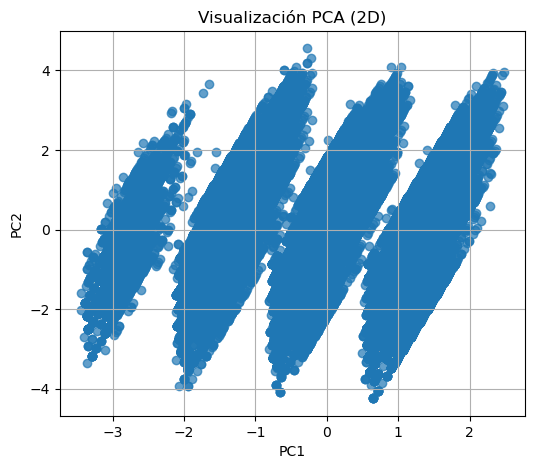

array([[-1.63680099, -0.24478177],
       [-1.71208269, -2.04520624],
       [-0.27976445, -0.58500086],
       ...,
       [ 0.02389669, -1.30793207],
       [ 1.38501019, -0.46280862],
       [-1.36938987,  0.17719608]], shape=(717996, 2))

In [17]:
PCA2D(x)

Se observa que los datos están distribuidos en cuatro cúmulos visibles, esto se tomará en cuenta al momento de implementar los métodos de SVM, en particular al considerar el kernel. Puede inferirse que un kernel radial resultará ser más apropiado para los presentes datos.

SEPARACIÓN DE DATOS

In [18]:
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.3, random_state=42, stratify=categoria)

In [19]:
print(len(X_train))
print(len(y_train))

502597
502597


In [20]:
def plot_confusion(y_true, y_pred, titulo):
    
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot(cmap="Blues")
    
    plt.title(titulo)
    plt.show()

Se escalan los datos

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
print(len(X_train))
print(len(y_train))

502597
502597


Se procede con el modelo

Modelo SVM con kernel lineal

In [23]:
from sklearn.svm import LinearSVC

modelo1 = LinearSVC(
    random_state=42,
    max_iter=5000
)

modelo1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [24]:
predm1=modelo1.predict(X_test)

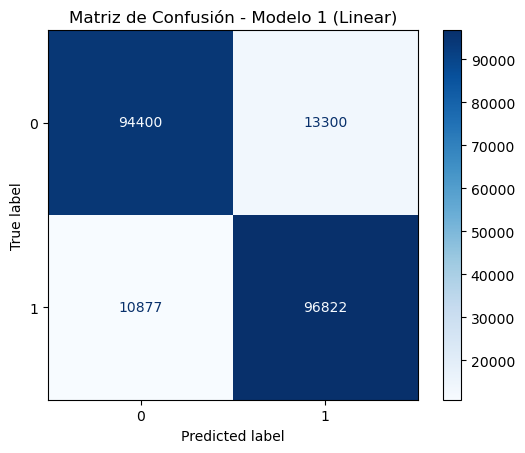

In [25]:
plot_confusion(y_test,predm1,"Matriz de Confusión - Modelo 1 (Linear)")

Modelo SVM con kernel radial

In [26]:
#El siguiente modelo es radial (rbf) sugerido así por el análisis del PCA.
modelo2=svm.SVC(kernel='rbf',random_state=42,max_iter=5000)

modelo2.fit(X_train, y_train)

C:\Users\aripi\anaconda3\envs\DataMining\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
predm2=modelo2.predict(X_test)

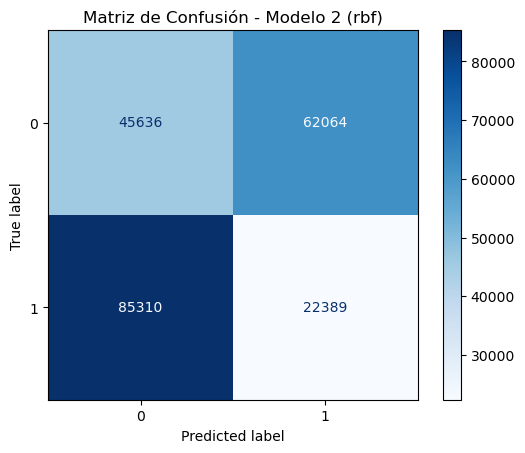

In [29]:
plot_confusion(y_test,predm2,"Matriz de Confusión - Modelo 2 (rbf)")

Modelo SVM optimizado

In [ ]:
param_dist = {
    'kernel': ['linear', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10], 
    'gamma': [0.1, 1, 10]
}

optim = GridSearchCV(
    estimator=modelo2,
    param_grid=param_dist,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)


print("Buscando los mejores hiperparámetros. Esto puede tardar un momento...")
optim.fit(X_train, y_train)

print("\n¡Búsqueda terminada!")
print(f"Mejor valor de Recall encontrado: {optim.best_score_:.4f}")
print("Mejores parámetros encontrados:")
print(optim.best_params_)

mejor_modelo = optim.best_estimator_

Buscando los mejores hiperparámetros. Esto puede tardar un momento...


In [ ]:
predm3=optim.predict(X_test)

In [ ]:
plot_confusion(y_test,ypredm3,"Matriz de Confusión - Modelo 3 (Optimizado rbf)")